# **Dataset Final - Tratamento Adequado e Filtros (WIP)**

In [3]:
%%capture
%run "/workspaces/CEA-1/análise de dados/tratamento_das_variaveis_explicativas.ipynb"

Colocar as colunas que já estão tratadas e prontas para serem analisadas

    'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas'

In [4]:
coluna_resposta = ['cls_fin_ajustada']

colunas_explicativas = ['dt_not_ano', 'preench_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante',
            'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada',  'tp_atd_ajustada', 
            'cls_eien',  'idade_anos', 'evol_num',     'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor',
    'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao',
    'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre',
    'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia',
    'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia',
    'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria',
    'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia',
    'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia',
    'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']

dados_finais = dados[coluna_resposta + colunas_explicativas]
print(dados_finais.columns.tolist())
print(f"Dimensões: {dados_finais.shape[0]} linhas × {dados_finais.shape[1]} colunas")

['cls_fin_ajustada', 'dt_not_ano', 'preench_ano', 'regiao', 'pais_nasc', 'sexo', 'cor', 'gestante', 'cod_prod_ajustada', 'dt_apl_ano', 'dose_ajustada', 'via_adm_ajustada', 'local_aplic_ajustada', 'tp_med', 'cls_ei_ajustada', 'tp_atd_ajustada', 'cls_eien', 'idade_anos', 'evol_num', 'dor_abdominal', 'dor_no_corpo', 'artralgia', 'cefaleia', 'dor', 'exantema_local', 'exantema', 'edema', 'eritema', 'calor', 'enduracao', 'abscesso_quente', 'lesao', 'linfonodomegalia', 'prurido', 'febre', 'nausea', 'emese', 'diarreia', 'tontura', 'sincope', 'parestesia', 'convulsao', 'confusao_mental', 'fraqueza', 'hipotensao', 'taquicardia', 'bradicardia', 'extremidades_frias', 'palidez', 'sudorese', 'urticaria', 'broncoespasmo', 'dispneia', 'angioedema', 'tremor', 'fotofobia', 'visao_turva', 'guillain_barre', 'encefalite', 'epilepsia', 'paralisia', 'purpura_trombocitopenica', 'manifestacoes_locais', 'manifestacoes_sistemicas']
Dimensões: 1083 linhas × 64 colunas


In [5]:
nome_do_ficheiro = 'dados_completos.csv'

# O parâmetro index=False evita que o pandas crie uma coluna extra com os números das linhas
dados_finais.to_csv(nome_do_ficheiro, index=False, encoding='utf-8')

Frequência da Variável Resposta:
cls_fin_ajustada
EANG                   48.85%
EI                     45.98%
EAG                     4.06%
Inclassificável         0.74%
EI - evento adverso     0.37%
Name: proportion, dtype: str

RANKING DE ASSOCIAÇÃO COM A RESPOSTA (V DE CRAMER)
                Variável  V de Cramer       P-Valor
manifestacoes_sistemicas     0.754507 4.094255e-132
                  tp_med     0.566549 7.581774e-145
    manifestacoes_locais     0.565385  1.164588e-73
         tp_atd_ajustada     0.521134 7.881649e-122
         cls_ei_ajustada     0.507252 1.272376e-210
               convulsao     0.462922  4.699706e-49
                     dor     0.421991  1.289096e-40
                cls_eien     0.402585 1.910786e-124
                 eritema     0.373313  1.286604e-31
          guillain_barre     0.352408  4.245920e-28
                   edema     0.352358  4.326824e-28
                   febre     0.328257  2.711142e-24
                cefaleia     0.327086  4.07

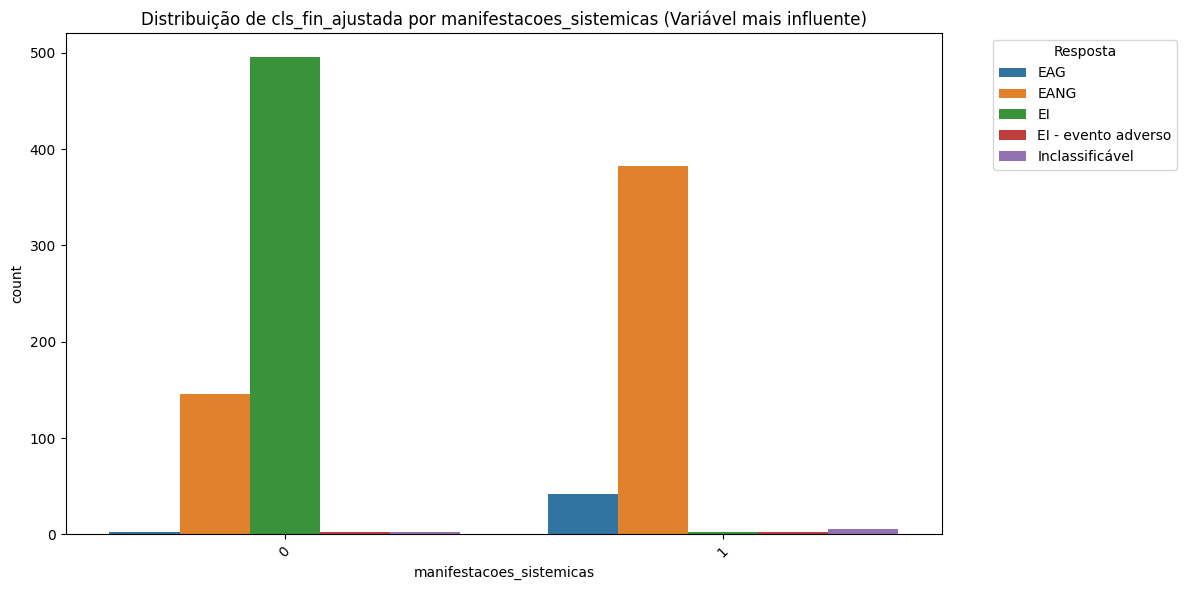

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── 1. DEFINIÇÃO DAS COLUNAS ──────────────────────────────────────────────────
coluna_resposta = 'cls_fin_ajustada'


# Criar cópia para análise
df_analise = dados_finais.copy()

# ── 2. TRANSFORMAÇÃO PARA CATEGÓRICAS ─────────────────────────────────────────
# Convertemos para string primeiro para garantir que códigos numéricos sejam tratados como labels
for col in df_analise.columns:
    df_analise[col] = df_analise[col].astype(str).astype('category')

print("Frequência da Variável Resposta:")
print(df_analise[coluna_resposta].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# ── 3. ANÁLISE ESTATÍSTICA (ASSOCIAÇÃO) ───────────────────────────────────────
resultados = []

for col in colunas_explicativas:
    # Criar tabela de contingência
    tab_cont = pd.crosstab(df_analise[col], df_analise[coluna_resposta])
    
    # Teste Qui-Quadrado (Independência)
    chi2, p_valor, dof, ex = stats.chi2_contingency(tab_cont)
    
    # Cálculo do V de Cramer (Força da associação de 0 a 1)
    n = tab_cont.sum().sum()
    min_dim = min(tab_cont.shape) - 1
    
    if min_dim > 0 and n > 0:
        v_cramer = np.sqrt(chi2 / (n * min_dim))
    else:
        v_cramer = 0
        
    resultados.append({
        'Variável': col,
        'P-Valor': p_valor,
        'V de Cramer': v_cramer,
        'Graus de Liberdade': dof
    })

# Criar DataFrame de resultados e ordenar pela força da associação
df_stats = pd.DataFrame(resultados).sort_values(by='V de Cramer', ascending=False)

# ── 4. EXIBIÇÃO DOS RESULTADOS ────────────────────────────────────────────────
print("\n" + "="*50)
print("RANKING DE ASSOCIAÇÃO COM A RESPOSTA (V DE CRAMER)")
print("="*50)
print(df_stats[['Variável', 'V de Cramer', 'P-Valor']].to_string(index=False))

# ── 5. VISUALIZAÇÃO DA TOP VARIÁVEL ──────────────────────────────────────────
top_var = df_stats.iloc[0]['Variável']
plt.figure(figsize=(12, 6))
sns.countplot(data=df_analise, x=top_var, hue=coluna_resposta)
plt.title(f"Distribuição de {coluna_resposta} por {top_var} (Variável mais influente)")
plt.xticks(rotation=45)
plt.legend(title='Resposta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Filtros:**


In [6]:
# 1. Criar uma cópia para preservar os dados originais
df_filtrado = dados_finais.copy()

df_filtrado = df_filtrado[
    (df_filtrado['dt_not_ano'] != 2023) &
    (~df_filtrado['pais_nasc'].isin(['VENEZUELA', 'PERU', 'OUTROS PAISES'])) &
    (~df_filtrado['cor'].isin(['Indígena'])) &
    (df_filtrado['gestante'] != 1) &
    (~df_filtrado['dt_apl_ano'].isin([2006, 2023, 2014, 2016, 2015])) &
    (df_filtrado['via_adm_ajustada'] != 'outros') &
    (~df_filtrado['local_aplic_ajustada'].isin(['Glúteo', 'Vasto Lateral da Coxa Esquerda', 'Vasto Lateral da Coxa Direito']))

]

# 3. Validar os resultados
print(f"Dimensões originais: {dados_finais.shape}")
print(f"Dimensões após filtros: {df_filtrado.shape}")

# Exemplo de verificação rápida para uma das colunas
print("\nVerificação 'pais_nasc' após filtro:")
print(df_filtrado['pais_nasc'].value_counts())

Dimensões originais: (1083, 64)
Dimensões após filtros: (1047, 64)

Verificação 'pais_nasc' após filtro:
pais_nasc
BRASIL           905
nao informado    142
Name: count, dtype: int64


In [5]:
# Iterar por todas as colunas do dataframe filtrado
for col in df_filtrado.columns:
    print(f"\n{'='*40}")
    print(f"COLUNA: {col}")
    print(f"{'='*40}")
    
    # Calcular contagem absoluta
    contagem = df_filtrado[col].value_counts()
    
    # Calcular porcentagem (normalize=True)
    porcentagem = df_filtrado[col].value_counts(normalize=True).mul(100).round(2)
    
    # Combinar os dois em um DataFrame para exibição limpa
    resumo = pd.DataFrame({
        'Frequência': contagem,
        'Porcentagem (%)': porcentagem.astype(str) + '%'
    })
    
    print(resumo)


COLUNA: cls_fin_ajustada
                     Frequência Porcentagem (%)
cls_fin_ajustada                               
EI                          368          48.55%
EANG                        353          46.57%
EAG                          29           3.83%
Inclassificável               7           0.92%
EI - evento adverso           1           0.13%

COLUNA: dt_not_ano
            Frequência Porcentagem (%)
dt_not_ano                            
2018               250          32.98%
2019               217          28.63%
2020               188           24.8%
2021                78          10.29%
2022                25            3.3%

COLUNA: preench_ano
             Frequência Porcentagem (%)
preench_ano                            
2018                250          32.98%
2019                217          28.63%
2020                188           24.8%
2021                 78          10.29%
2022                 25            3.3%

COLUNA: regiao
              Frequência Por

In [1]:
# Correlação para VARIÁVEIS CATEGÓRICAS: Cramér's V

# Função para calcular Cramér's V
cramers_v <- function(x, y) {
  chi2 <- chisq.test(x, y, correct = FALSE)$statistic
  n <- sum(table(x, y))
  min_dim <- min(nlevels(as.factor(x)), nlevels(as.factor(y))) - 1
  return(sqrt(chi2 / (n * min_dim)))
}

# Selecionar todas as colunas (ou apenas categóricas se houver)
dados_categoricas <- dados_finais[, sapply(dados_finais, is.character) | sapply(dados_finais, is.factor)]

# Se não houver categóricas puras, converter numéricas em categóricas
if (ncol(dados_categoricas) == 0) {
  dados_categoricas <- data.frame(lapply(dados_finais, as.factor))
}

# Criar matriz de Cramér's V
n_vars <- ncol(dados_categoricas)
cramers_matrix <- matrix(1, n_vars, n_vars)
colnames(cramers_matrix) <- names(dados_categoricas)
rownames(cramers_matrix) <- names(dados_categoricas)

for (i in 1:n_vars) {
  for (j in 1:n_vars) {
    if (i != j) {
      cramers_matrix[i, j] <- cramers_v(dados_categoricas[[i]], dados_categoricas[[j]])
    }
  }
}

# Exibir tabela
cat("\n=== MATRIX DE CRAMÉR'S V (Associação entre Categóricas) ===\n\n")
print(round(cramers_matrix, 3))

# Salvar como CSV
write.csv(round(cramers_matrix, 4), "/workspaces/CEA-1/cramers_v_matrix.csv")
cat("\n✓ Tabela salva em: /workspaces/CEA-1/cramers_v_matrix.csv\n")



SyntaxError: invalid syntax (3463784460.py, line 4)